# Inverse design of a planewave absorber with JAX + optax

Dolphindes has two ways of doing simple inverse design via its simple FDFD Maxwell solver. The first is by working directly with the polarization objectives, for which we have written out custom derivative rules. This is not always convenient: writing objectives in terms of polarization is necessary for limits but not always natural for design. Thus, the second method is with a custom jax wrapper that allows you to differentiate through the field solve.

The key ingredient is `dolphindes.maxwell.jax_fdfd.build_jax_field_solver`. You hand it a
solver and it hands back a `jax.grad`-differentiable function `field(source, chi) -> Ez`,
where `Ez` is flattened. The heavy linear solve still runs on the CPU via scipy; JAX just
wraps it so `jax.grad` works. JAX is an optional dependency (`pip install dolphindes[jax]`)
and the solver classes themselves never import it.

**Build it once.** `build_jax_field_solver` copies the Maxwell operator into a native-JAX
sparse array, so call it outside your optimization loop and reuse the returned function.

**Physics.** The time-averaged absorbed power is

$$ f = \frac{\omega}{2}\int \mathrm{Im}\,\chi(\mathbf r)\,|E_z(\mathbf r)|^2\, d\mathbf r . $$

We parametrize the structure by a density $\rho(\mathbf r)\in[0,1]$ over a design region,
with local susceptibility $\chi(\mathbf r) = \rho(\mathbf r)\,\chi_\mathrm{mat}$, and
maximize $f$ over $\rho$. To keep $\rho$ in $[0,1]$ we optimize an unconstrained latent
field through a sigmoid.

> **64-bit JAX is required.** 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import optax

from dolphindes import geometry
from dolphindes.maxwell import TM_FDFD
from dolphindes.maxwell.jax_fdfd import build_jax_field_solver

## 1. Geometry, source, and solver

A unit-amplitude plane wave travelling in $+x$ is launched by a line current just inside
the left PML. The square design region sits in the middle, padded from the PML by vacuum.

grid = 60 x 60,  design pixels = 400


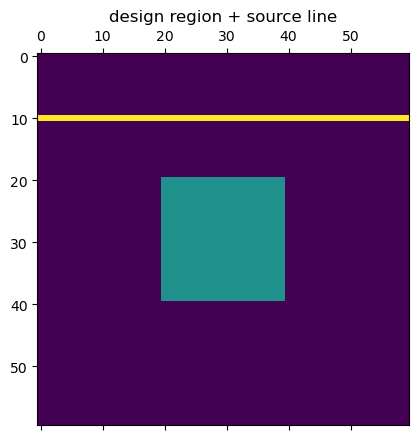

In [ ]:
wavelength = 1.0
omega = 2 * np.pi / wavelength

px_per_wavelength = 20
dl = 1.0 / px_per_wavelength

des_size = 1.0     # square design region side length (in wavelengths)
pml_sep = 0.5      # vacuum padding between design region and PML
pml_thick = 0.5

M = int(des_size / dl)
Nsep = int(pml_sep / dl)
Npml = int(pml_thick / dl)
Nx = Ny = M + 2 * (Nsep + Npml)

# design region: where material is allowed to be placed
des_mask = np.zeros((Nx, Ny), dtype=bool)
des_mask[Npml + Nsep:-(Npml + Nsep), Npml + Nsep:-(Npml + Nsep)] = True
des_idx = np.where(des_mask.ravel())[0]
Ndes = des_idx.size

# unit-amplitude planewave in +x: line current just inside the left PML
ji = np.zeros((Nx, Ny), dtype=complex)
ji[Npml, :] = 2.0 / dl

geo = geometry.CartesianFDFDGeometry(Nx=Nx, Ny=Ny, Npmlx=Npml, Npmly=Npml, dx=dl, dy=dl)
solver = TM_FDFD(omega, geo)

print(f"grid = {Nx} x {Ny},  design pixels = {Ndes}")
plt.matshow(des_mask + np.real(ji) * dl)
plt.title("design region + source line")
plt.show()

## 2. Incident field

The incident (vacuum) field is just the ordinary numpy solve. A correctly normalized
unit-amplitude plane wave has $|E_z|\approx 1$ in the interior.

incident |E| near center: 1.0126723055251141


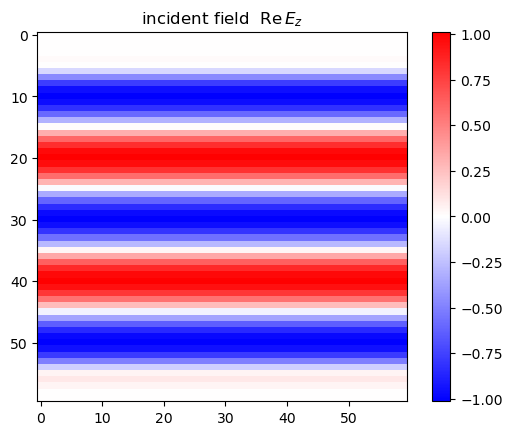

In [ ]:
ei = solver.get_TM_field(ji)   # ordinary numpy solve, no chi -> vacuum
print("incident |E| near center:", abs(ei[Nx // 2, Ny // 2]))
plt.imshow(np.real(ei), cmap="bwr")
plt.title(r"incident field  $\mathrm{Re}\,E_z$")
plt.colorbar()
plt.show()

## 3. A differentiable objective

`build_jax_field_solver` gives us the differentiable solve. `density_to_chi` places the
design density into a full-grid susceptibility, and `absorption` runs the solve and
returns the absorbed power.

In [ ]:
chi_material = 4 + 0.1j         # lossy dielectric (Im > 0 gives absorption)
im_chi = float(np.imag(chi_material))
dA = dl * dl
ji_j = jnp.asarray(ji)

# Build the differentiable field solve ONCE, outside the optimization loop.
# field(source, chi) -> flattened Ez, differentiable in both arguments.
field = build_jax_field_solver(solver)

def density_to_chi(rho):
    "Scatter the design density into a flattened full-grid susceptibility."
    chi_flat = jnp.zeros(Nx * Ny, dtype=jnp.complex128)
    return chi_flat.at[des_idx].set(rho.astype(jnp.complex128) * chi_material)

def absorption(latent):
    "Absorbed power; rho = sigmoid(latent) keeps the density in [0, 1]."
    rho = jax.nn.sigmoid(latent)
    chi = density_to_chi(rho)
    Ez = field(ji_j, chi)                            # differentiable solve (flat)
    return 0.5 * omega * jnp.sum(rho * im_chi * jnp.abs(Ez[des_idx]) ** 2) * dA

# jax.grad flows through `field`: the forward + adjoint solves are handled
# automatically by the custom_linear_solve rule inside dolphindes.
value_and_grad = jax.value_and_grad(lambda latent: -absorption(latent))

## 4. Optimize with optax

Adam on the latent field. Each step is one forward solve (the objective) plus one adjoint
solve (the gradient). We start from `latent = 0.5`. This is a natural way to do optimization with jax - but a wrapper with nlopt would be relatively easy to implement. 

Running this cell requires optax, which is not an explicit requirement of Dolphindes.

iter    0   absorption = 0.1356
iter   25   absorption = 0.5393
iter   50   absorption = 0.6120
iter   75   absorption = 0.6561
iter   99   absorption = 0.6804


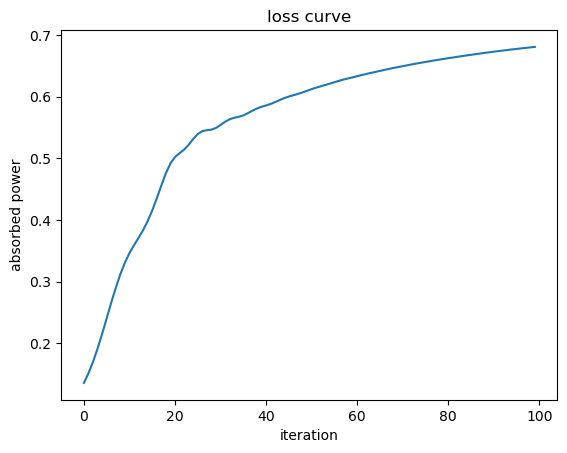

In [ ]:
latent = jnp.zeros(Ndes) + 0.5
optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(latent)

history = []
n_iters = 100
for i in range(n_iters):
    neg_abs, grad = value_and_grad(latent)
    updates, opt_state = optimizer.update(grad, opt_state)
    latent = optax.apply_updates(latent, updates)
    history.append(-float(neg_abs))
    if i % 25 == 0 or i == n_iters - 1:
        print(f"iter {i:4d}   absorption = {history[-1]:.4f}")

plt.plot(history)
plt.xlabel("iteration")
plt.ylabel("absorbed power")
plt.title("loss curve")
plt.show()

## 5. Optimized structure and field

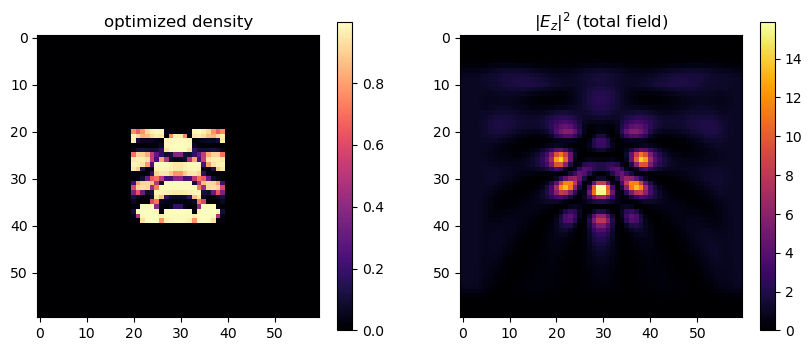

In [ ]:
rho_opt = np.asarray(jax.nn.sigmoid(latent))
rho_grid = np.zeros(Nx * Ny)
rho_grid[des_idx] = rho_opt
rho_grid = rho_grid.reshape(Nx, Ny)

chi_opt = np.asarray(density_to_chi(jnp.asarray(rho_opt))).reshape(Nx, Ny)
Ez_opt = solver.get_TM_field(ji, chi_opt)   # numpy solve for plotting

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(rho_grid, cmap="magma")
ax[0].set_title("optimized density")
plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(np.abs(Ez_opt) ** 2, cmap="inferno")
ax[1].set_title(r"$|E_z|^2$ (total field)")
plt.colorbar(im1, ax=ax[1])
plt.show()